# MLP vs CNN on Fashion-MNIST — Practice Notebook

Train an MLP and a small CNN on Fashion-MNIST with the shared `Trainer` loop, then compare their training curves and validation accuracy.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from dl_roadmap.engine import ClassPredictor, Trainer, TrainerConfig
from dl_roadmap.metrics.classification import evaluate_multiclass_classification
from dl_roadmap.utils import LoggerConfig, seed_everything, setup_logger
from dl_roadmap.visualization import plot_training_history_on_ax

In [3]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

seed_everything()
setup_logger(LoggerConfig(disable_logging=True))

## Dataset

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="../data/raw",
    train=True,
    download=True,
    transform=transform,
)
val_dataset = datasets.FashionMNIST(
    root="../data/raw",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 714kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 8.41MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.6MB/s]


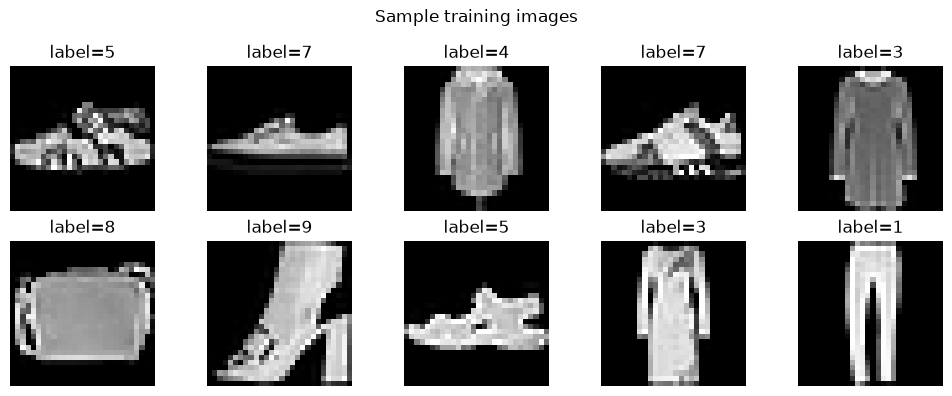

In [5]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for image, label, ax in zip(images, labels, axes.flatten()):
    ax.imshow(image.permute(1, 2, 0), cmap="gray")
    ax.set_title(f"label={label.item()}")
    ax.axis("off")

plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

## Training

In [6]:
mlp_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

mlp_opt = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
mlp_loss_fn = nn.CrossEntropyLoss()

mlp_trainer_config = TrainerConfig(epochs=10)
mlp_trainer = Trainer(mlp_model, mlp_opt, mlp_loss_fn, config=mlp_trainer_config)
mlp_trainer.fit(train_loader, val_loader)

Epoch 10/10: 100%[====================] 9380/9380 :: eta=00:00, train_loss=0.2288, val_loss=0.3382


In [7]:
cnn_model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Flatten(),
    nn.Linear(8 * 7 * 7, 32),
    nn.ReLU(),
    nn.Linear(32, 10),
)

cnn_opt = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
cnn_loss_fn = nn.CrossEntropyLoss()

cnn_trainer_config = TrainerConfig(epochs=10)
cnn_trainer = Trainer(cnn_model, cnn_opt, cnn_loss_fn, config=cnn_trainer_config)
cnn_trainer.fit(train_loader, val_loader)

Epoch  1/10  0%[                    ] 0/9380 :: eta=?

Epoch 10/10: 100%[====================] 9380/9380 :: eta=00:00, train_loss=0.2103, val_loss=0.2731


## Results

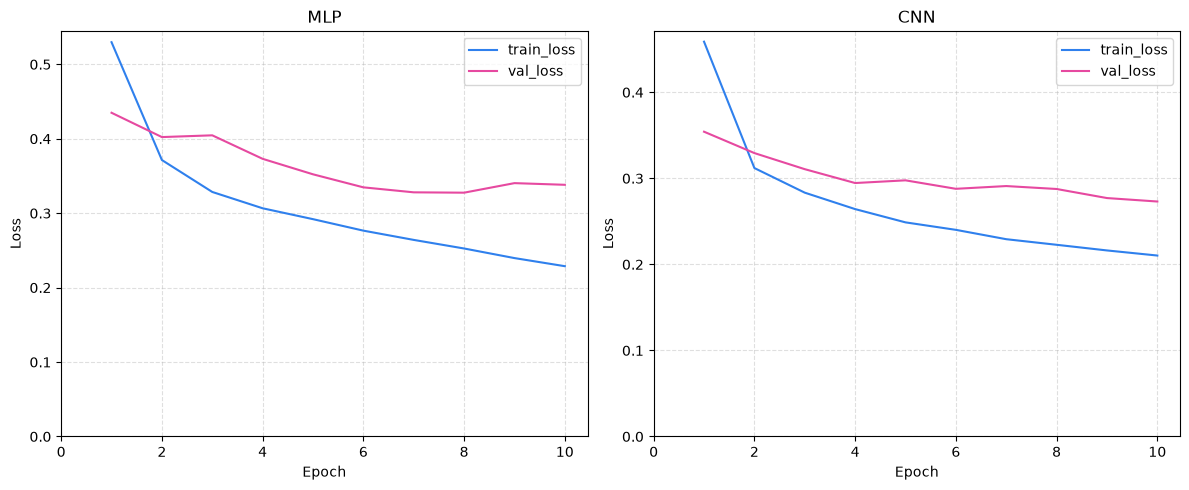

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_training_history_on_ax(ax=axes[0], **mlp_trainer.history, title="MLP")
plot_training_history_on_ax(ax=axes[1], **cnn_trainer.history, title="CNN")

plt.tight_layout()
plt.show()

In [9]:
X_val = torch.cat([xb for xb, *_ in val_loader])
y_val = torch.cat([yb for *_, yb in val_loader])


def _get_statistics(model: nn.Module) -> dict[str, float]:
    predictor = ClassPredictor(model)
    y_pred = predictor.predict(X_val)

    metrics = evaluate_multiclass_classification(y_pred, y_val)
    parameters = sum(p.numel() for p in model.parameters())

    return {**metrics, "parameters": parameters}

In [10]:
pd.DataFrame(
    data=[
        _get_statistics(mlp_model),
        _get_statistics(cnn_model),
    ],
    index=["MLP", "CNN"],
)

,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,parameters
MLP,0.8795,0.882936,0.8795,0.880193,0.882936,0.8795,0.880193,235146
CNN,0.9040,0.903628,0.9040,0.902274,0.903628,0.9040,0.902274,14274
